In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Literal, Dict, List

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.random import PRNGKey
from jax.flatten_util import ravel_pytree
import gymnax


In [ ]:
# ---------------------------
# Step 0: Shared config (continuous actions)
# ---------------------------

@dataclass
class Config:
    seed: int = 42
    env_name: str = "Pendulum-v1"

    # MDP / return
    gamma: float = 0.99
    horizon: int = 200  # overridden by env_params.max_steps_in_episode if different

    # Continuous action policy (match Pendulum's continuous control)
    action_max: float = 2.0  # torque bound; action = action_max * tanh(net_out)

    # Neural policy (MLP)
    hidden_sizes: Tuple[int, int] = (64, 64)
    init_scale: float = 1e-2

    # Shared evaluation budget (keep ES vs CEM comparable)
    popsize: int = 128
    fitness_episodes: int = 3   # average rollouts per candidate to reduce noise (1 is OK too)

    iters: int = 200
    eval_every: int = 5

    # ---- CEM hyperparams ----
    cem_init_std: float = 0.5
    cem_elite_frac: float = 0.2   # more elites = more stable updates
    cem_min_std: float = 0.10     # prevent premature collapse
    cem_alpha: float = 0.5        # smoothing / momentum (0.3–0.6 typical)

    # ---- ES hyperparams ----
    es_sigma: float = 0.10        # noise scale in parameter space
    es_lr: float = 0.02           # learning rate for theta update

    # Backwards-compatible aliases
    @property
    def cem_iters(self): return self.iters
    @property
    def cem_popsize(self): return self.popsize
    @property
    def cem_fitness_episodes(self): return self.fitness_episodes

    @property
    def es_iters(self): return self.iters
    @property
    def es_popsize(self): return self.popsize
    @property
    def es_fitness_episodes(self): return self.fitness_episodes

cfg = Config()
cfg


Config(seed=42, env_name='Pendulum-v1', gamma=0.99, horizon=200, action_max=2.0, hidden_sizes=(64, 64), init_scale=0.01, popsize=128, fitness_episodes=3, iters=200, eval_every=5, cem_init_std=0.5, cem_elite_frac=0.2, cem_min_std=0.1, cem_alpha=0.5, es_sigma=0.1, es_lr=0.02)

In [ ]:
# ---------------------------
# Step 2: Neural policy πθ
# ---------------------------

def initialize_mlp(layer_sizes: Tuple[int, ...], key: PRNGKey, scale: float = 1e-1):
    """Return a list of (W,b) tuples."""
    params = []
    keys = jr.split(key, 2 * (len(layer_sizes) - 1))
    k = 0
    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = jr.normal(keys[k], (in_dim, out_dim)) * scale
        b = jnp.zeros((out_dim,))
        params.append((W, b))
        k += 1
    return params


In [4]:
def mlp_forward(params, x: jnp.ndarray) -> jnp.ndarray:
    """Simple MLP forward pass."""
    for (W, b) in params[:-1]:
        x = jnp.dot(x, W) + b
        x = jax.nn.relu(x)
    W, b = params[-1]
    return jnp.dot(x, W) + b


In [5]:
def policy_raw(params, obs: jnp.ndarray) -> jnp.ndarray:
    """Raw (unbounded) action output."""
    return mlp_forward(params, obs).squeeze()  # scalar

def policy_action_deterministic(params, obs: jnp.ndarray, cfg: Config) -> jnp.ndarray:
    """Deterministic continuous action in [-action_max, action_max]."""
    u = cfg.action_max * jnp.tanh(policy_raw(params, obs))
    return jnp.array([u], dtype=jnp.float32)


In [6]:
# ---------------------------
# Step 3: Rollout -> Return (Fitness)  (deterministic policy, continuous actions)
# ---------------------------

def rollout_return(env, env_params, params, key: PRNGKey, cfg: Config) -> jnp.ndarray:
    """One episode rollout, returns discounted return."""
    key, k_reset = jr.split(key, 2)
    obs, state = env.reset(k_reset, env_params)

    def step_fn(carry, _t):
        key, obs, state, G, gpow, alive = carry
        key, k_step = jr.split(key, 2)

        action = policy_action_deterministic(params, obs, cfg)
        next_obs, next_state, reward, done, _info = env.step(k_step, state, action, env_params)

        # Stop accumulating after termination (Pendulum doesn't usually terminate early, but keep it consistent)
        alive_next = alive * (1.0 - done)
        G = G + gpow * reward * alive_next
        gpow = gpow * cfg.gamma

        return (key, next_obs, next_state, G, gpow, alive_next), None

    horizon = int(env_params.max_steps_in_episode) if hasattr(env_params, "max_steps_in_episode") else int(cfg.horizon)
    init = (key, obs, state, jnp.array(0.0), jnp.array(1.0), jnp.array(1.0))
    (key, obs, state, G, gpow, alive), _ = jax.lax.scan(step_fn, init, xs=None, length=horizon)
    return G


def fitness(env, env_params, params, key: PRNGKey, cfg: Config, episodes: int) -> jnp.ndarray:
    """Average return over `episodes` rollouts."""
    keys = jr.split(key, episodes)
    returns = jax.vmap(lambda k: rollout_return(env, env_params, params, k, cfg))(keys)
    return jnp.mean(returns)


In [7]:
# JIT compile fitness over a batch of candidates (big speed-up)
def make_population_fitness_fn(env, env_params, unravel, cfg: Config, episodes: int):
    @jax.jit
    def pop_fit(thetas: jnp.ndarray, key: PRNGKey) -> jnp.ndarray:
        keys = jr.split(key, thetas.shape[0])

        def one(theta, k):
            p = unravel(theta)
            return fitness(env, env_params, p, k, cfg, episodes)

        return jax.vmap(one)(thetas, keys)

    return pop_fit


In [8]:
# ---------------------------
# Step 5: CEM optimizer
# ---------------------------

def train_cem(env, env_params, theta0: jnp.ndarray, unravel, cfg: Config) -> Dict[str, List[float]]:
    dim = theta0.shape[0]
    elite_n = max(1, int(cfg.cem_popsize * cfg.cem_elite_frac))

    key = jr.PRNGKey(cfg.seed)

    mu = theta0
    sigma = jnp.ones((dim,)) * cfg.cem_init_std  # diagonal gaussian

    pop_fit = make_population_fitness_fn(env, env_params, unravel, cfg, cfg.cem_fitness_episodes)

    hist = {"iter": [], "best": [], "elite_mean": [], "mu_eval": [], "sigma_mean": []}

    for it in range(1, cfg.cem_iters + 1):
        key, k_pop, k_mu = jr.split(key, 3)

        # sample population
        eps = jr.normal(k_pop, (cfg.cem_popsize, dim))
        thetas = mu[None, :] + eps * sigma[None, :]

        # evaluate fitness
        fits = pop_fit(thetas, k_pop)

        # pick elites
        idx = jnp.argsort(fits)[-elite_n:]
        elites = thetas[idx]
        elite_fits = fits[idx]

        # update distribution
        new_mu = jnp.mean(elites, axis=0)
        new_sigma = jnp.std(elites, axis=0)
        new_sigma = jnp.maximum(new_sigma, cfg.cem_min_std)

        # smoothing
        mu = cfg.cem_alpha * mu + (1.0 - cfg.cem_alpha) * new_mu
        sigma = cfg.cem_alpha * sigma + (1.0 - cfg.cem_alpha) * new_sigma

        # evaluate current mean policy
        mu_eval = float(fitness(env, env_params, unravel(mu), k_mu, cfg, cfg.cem_fitness_episodes))

        # log
        hist["iter"].append(it)
        hist["best"].append(float(jnp.max(fits)))
        hist["elite_mean"].append(float(jnp.mean(elite_fits)))
        hist["mu_eval"].append(mu_eval)
        hist["sigma_mean"].append(float(jnp.mean(sigma)))

        if it % cfg.eval_every == 0 or it == 1 or it == cfg.cem_iters:
            print(
                f"[CEM] iter={it:03d}  best(pop)={hist['best'][-1]:8.1f}  "
                f"elite_mean={hist['elite_mean'][-1]:8.1f}  mu_eval={mu_eval:8.1f}  "
                f"mean_sigma={hist['sigma_mean'][-1]:.3f}"
            )

    return hist


In [ ]:
# ---------------------------
# Step 6: ES optimizer (antithetic + rank-normalized utilities)
# ---------------------------

def _rank_utilities(x: jnp.ndarray) -> jnp.ndarray:
    """Map returns -> rank-based utilities in [-0.5, 0.5]."""
    n = x.shape[0]
    ranks = jnp.argsort(jnp.argsort(x))  # 0..n-1
    util = ranks.astype(jnp.float32) / jnp.maximum(1, (n - 1))  # [0,1]
    return util - 0.5

def train_es(env, env_params, theta0: jnp.ndarray, unravel, cfg: Config) -> Dict[str, List[float]]:
    """Antithetic ES with rank-normalized utilities (much lower variance)."""
    dim = theta0.shape[0]
    key = jr.PRNGKey(cfg.seed)

    theta = theta0
    pop_fit = make_population_fitness_fn(env, env_params, unravel, cfg, cfg.es_fitness_episodes)

    hist = {"iter": [], "theta_eval": []}

    for it in range(1, cfg.es_iters + 1):
        key, k_eps, k_plus, k_minus, k_eval = jr.split(key, 5)

        # Sample perturbations
        eps = jr.normal(k_eps, (cfg.es_popsize, dim))

        thetas_plus = theta[None, :] + cfg.es_sigma * eps
        thetas_minus = theta[None, :] - cfg.es_sigma * eps

        # Evaluate plus/minus with *independent* keys
        f_plus = pop_fit(thetas_plus, k_plus)
        f_minus = pop_fit(thetas_minus, k_minus)

        # Rank-normalize across all 2*popsize samples
        all_f = jnp.concatenate([f_plus, f_minus], axis=0)
        util = _rank_utilities(all_f)
        u_plus = util[: cfg.es_popsize]
        u_minus = util[cfg.es_popsize :]

        # Antithetic gradient estimate
        weights = (u_plus - u_minus)[:, None]  # (popsize, 1)
        grad_est = jnp.mean(weights * eps, axis=0) / cfg.es_sigma

        theta = theta + cfg.es_lr * grad_est

        # Evaluate current theta
        theta_eval = float(fitness(env, env_params, unravel(theta), k_eval, cfg, cfg.es_fitness_episodes))
        hist["iter"].append(it)
        hist["theta_eval"].append(theta_eval)

        if it % cfg.eval_every == 0 or it == 1 or it == cfg.es_iters:
            print(f"[ES ] iter={it:03d}  theta_eval={theta_eval:8.1f}")

    return hist


Using horizon=200 steps per episode
Initial deterministic fitness (avg return): -657.8560791015625
[CEM] iter=001  best(pop)=  -371.5  elite_mean=  -545.9  mu_eval=  -536.3  mean_sigma=0.492
[CEM] iter=005  best(pop)=    -1.5  elite_mean=  -505.4  mu_eval=  -602.8  mean_sigma=0.464
[CEM] iter=010  best(pop)=  -420.5  elite_mean=  -526.3  mu_eval=  -572.0  mean_sigma=0.430
[CEM] iter=015  best(pop)=  -454.4  elite_mean=  -531.4  mu_eval=  -588.8  mean_sigma=0.398
[CEM] iter=020  best(pop)=  -372.5  elite_mean=  -519.4  mu_eval=  -686.2  mean_sigma=0.369
[CEM] iter=025  best(pop)=  -334.8  elite_mean=  -504.6  mu_eval=  -714.0  mean_sigma=0.343
[CEM] iter=030  best(pop)=  -426.8  elite_mean=  -543.1  mu_eval=  -619.7  mean_sigma=0.316
[CEM] iter=035  best(pop)=  -407.9  elite_mean=  -511.7  mu_eval=  -600.8  mean_sigma=0.294
[CEM] iter=040  best(pop)=  -358.9  elite_mean=  -508.5  mu_eval=  -614.0  mean_sigma=0.272
[CEM] iter=045  best(pop)=  -349.0  elite_mean=  -495.0  mu_eval=  -495.1

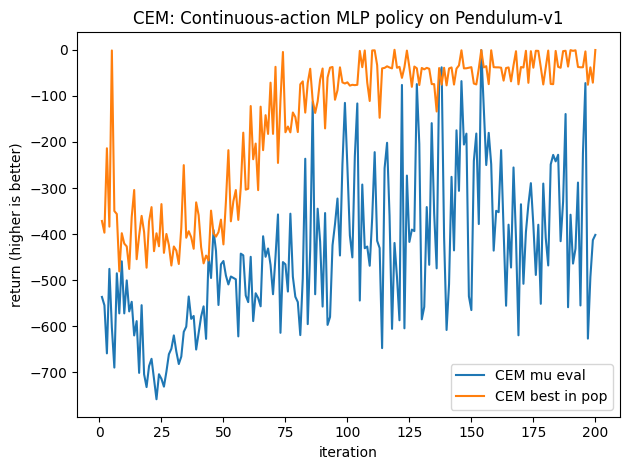


Done.


In [ ]:
# ---------------------------
# Step 7: Run + Plot 
# ---------------------------

import matplotlib.pyplot as plt

# Step 1: Environment / MDP
env, env_params = gymnax.make(cfg.env_name)

# Override horizon from env params if present
horizon = int(env_params.max_steps_in_episode) if hasattr(env_params, "max_steps_in_episode") else int(cfg.horizon)
print(f"Using horizon={horizon} steps per episode")

# Get obs dimension
key = jr.PRNGKey(cfg.seed)
key, k_reset = jr.split(key, 2)
obs, _state = env.reset(k_reset, env_params)
obs_dim = int(obs.shape[0])

# Step 2: Initialize policy params (MLP) -> logits over discrete actions
key, k_init = jr.split(key, 2)
layer_sizes = (obs_dim, *cfg.hidden_sizes, 1)
params0 = initialize_mlp(layer_sizes, key=k_init, scale=cfg.init_scale)

# Flatten params for evolution optimizers
theta0, unravel = ravel_pytree(params0)

print("Initial deterministic fitness (avg return):",
      float(fitness(env, env_params, params0, key, cfg, episodes=cfg.cem_fitness_episodes)))

# ---- Run CEM ----
hist_cem = train_cem(env, env_params, theta0, unravel, cfg)

# Plot CEM curve
plt.figure()
plt.plot(hist_cem["iter"], hist_cem["mu_eval"], label="CEM mu eval")
plt.plot(hist_cem["iter"], hist_cem["best"], label="CEM best in pop")
plt.xlabel("iteration")
plt.ylabel("return (higher is better)")
plt.title("CEM: Continuous-action MLP policy on Pendulum-v1")
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")


[ES ] iter=001  theta_eval=  -587.6
[ES ] iter=005  theta_eval=  -560.2
[ES ] iter=010  theta_eval=  -591.3
[ES ] iter=015  theta_eval=  -515.0
[ES ] iter=020  theta_eval=  -665.9
[ES ] iter=025  theta_eval=  -606.7
[ES ] iter=030  theta_eval=  -584.2
[ES ] iter=035  theta_eval=  -587.8
[ES ] iter=040  theta_eval=  -506.9
[ES ] iter=045  theta_eval=  -410.9
[ES ] iter=050  theta_eval=  -622.5
[ES ] iter=055  theta_eval=  -449.9
[ES ] iter=060  theta_eval=  -393.3
[ES ] iter=065  theta_eval=  -490.4
[ES ] iter=070  theta_eval=  -514.9
[ES ] iter=075  theta_eval=  -531.6
[ES ] iter=080  theta_eval=  -415.1
[ES ] iter=085  theta_eval=  -539.7
[ES ] iter=090  theta_eval=  -653.9
[ES ] iter=095  theta_eval=  -460.7
[ES ] iter=100  theta_eval=  -542.2
[ES ] iter=105  theta_eval=  -577.0
[ES ] iter=110  theta_eval=  -523.1
[ES ] iter=115  theta_eval=  -484.3
[ES ] iter=120  theta_eval=  -548.8
[ES ] iter=125  theta_eval=  -573.7
[ES ] iter=130  theta_eval=  -492.5
[ES ] iter=135  theta_eval= 

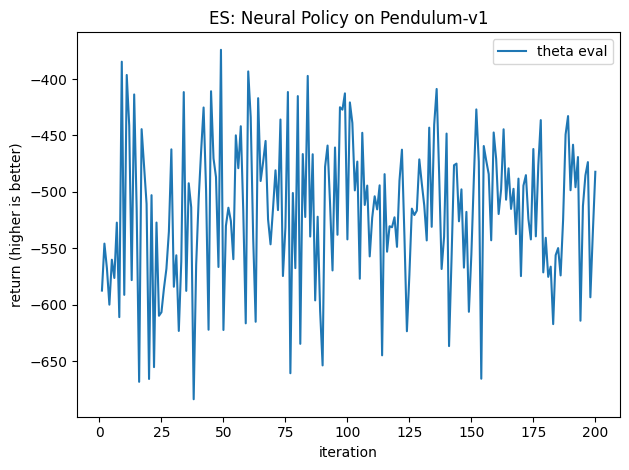

In [11]:
hist = train_es(env, env_params, theta0, unravel, cfg)

it = np.array(hist["iter"])
plt.figure()
plt.plot(it, hist["theta_eval"], label="theta eval")
plt.xlabel("iteration")
plt.ylabel("return (higher is better)")
plt.title("ES: Neural Policy on Pendulum-v1")

plt.legend()
plt.tight_layout()
plt.show()